# B-H Curve Extrapolation into μ₀

Deep in magnetic saturation, the incremental permeability of any material approaches the permeability of free space μ₀, because the magnetisation **M** saturates (dM/dH → 0) and additional flux comes purely from the applied field:

$$\mathbf{B} = \mu_0 (\mathbf{H} + \mathbf{M}) \quad \Rightarrow \quad \frac{\mathrm{d}B}{\mathrm{d}H} \xrightarrow{\text{sat.}} \mu_0$$

Equivalently, in the H-B form used by Elmer:

$$\frac{\mathrm{d}H}{\mathrm{d}B} \xrightarrow{\text{sat.}} \frac{1}{\mu_0} \approx 795{,}775 \; \text{A/(m·T)}$$

The `m350-50a_20c.pmf` table ends at B = 2.4 T. If the solver proposes B > 2.4 T during a Newton iteration, the cubic spline **extrapolates** and can overflow. This notebook builds a smooth extrapolation that converges to the correct asymptotic slope.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

mu_0 = 4 * np.pi * 1e-7  # H/m
print(f"μ₀ = {mu_0:.6e} H/m")
print(f"1/μ₀ = {1/mu_0:,.0f} A/(m·T)  ← asymptotic dH/dB slope")

μ₀ = 1.256637e-06 H/m
1/μ₀ = 795,775 A/(m·T)  ← asymptotic dH/dB slope


## 1. Load the M350-50A data

In [2]:
# Data from m350-50a_20c.pmf
# Columns: B [T], H [A/m]  (Elmer H-B Curve format: Variable coupled iter)
B_data = np.array([
    0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
    1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9,
    1.956, 2.1, 2.2, 2.2701, 2.4
])

H_data = np.array([
    0, 34.8, 46, 53.7, 60.6, 67.4, 74.6, 82.6, 91.8, 103,
    119, 141, 178, 250, 455, 1180, 3020, 6100, 10700, 25000,
    35000, 75000, 115000, 150000, 229580
])

# PCHIP interpolant for the original data (monotone, no oscillations)
pchip = PchipInterpolator(B_data, H_data)

# Slope at the last data point
B_last, H_last = B_data[-1], H_data[-1]
dHdB_last_segment = (H_data[-1] - H_data[-2]) / (B_data[-1] - B_data[-2])
dHdB_last_pchip   = float(pchip(B_last, 1))  # first derivative from PCHIP

print(f"Last data point : B = {B_last} T,  H = {H_last:,} A/m")
print(f"Slope from last segment  dH/dB = {dHdB_last_segment:,.0f} A/(m·T)")
print(f"Slope from PCHIP         dH/dB = {dHdB_last_pchip:,.0f} A/(m·T)")
print(f"Asymptotic target  1/μ₀        = {1/mu_0:,.0f} A/(m·T)")
print(f"\nIncremental μᵣ at last point (segment) = {1/(mu_0 * dHdB_last_segment):.3f}")

Last data point : B = 2.4 T,  H = 229,580.0 A/m
Slope from last segment  dH/dB = 612,625 A/(m·T)
Slope from PCHIP         dH/dB = 686,238 A/(m·T)
Asymptotic target  1/μ₀        = 795,775 A/(m·T)

Incremental μᵣ at last point (segment) = 1.299


## 2. Smooth extrapolation

We want a function H(B) for B > B_last that satisfies:

| Condition | Formula |
|---|---|
| Continuity | H(B_last) = H_last |
| Slope continuity | H'(B_last) = dH/dB\|_last |
| Asymptotic slope | H'(B → ∞) = 1/μ₀ |

A clean closed-form that satisfies all three conditions:

$$H(B) = H_{\text{last}} + \frac{1}{\mu_0}(B - B_{\text{last}}) + \frac{\Delta}{k}\left(1 - e^{-k(B - B_{\text{last}})}\right)$$

where $\Delta = \left.\frac{\mathrm{d}H}{\mathrm{d}B}\right|_{B_{\text{last}}} - \frac{1}{\mu_0}$ and $k > 0$ controls how quickly the slope converges to $1/\mu_0$ (transition width ≈ $1/k$ in Tesla).

In [3]:
def extrapolate_H(B, B_last, H_last, dHdB_last, k):
    """
    Smooth extrapolation of H(B) beyond B_last that asymptotes to slope 1/μ₀.

    Parameters
    ----------
    B         : array-like, field values to evaluate (must be >= B_last)
    B_last    : float, last B value in the data table [T]
    H_last    : float, H at B_last [A/m]
    dHdB_last : float, slope dH/dB at B_last [A/(m·T)]
    k         : float, transition rate [1/T]; larger k = faster convergence to 1/μ₀
    """
    B = np.asarray(B)
    delta = dHdB_last - 1 / mu_0
    x = B - B_last
    return H_last + (1 / mu_0) * x + (delta / k) * (1 - np.exp(-k * x))


def dHdB_extrap(B, B_last, dHdB_last, k):
    """Derivative of the extrapolation (for verification and permeability plots)."""
    delta = dHdB_last - 1 / mu_0
    return 1 / mu_0 + delta * np.exp(-k * (B - B_last))


# Use the PCHIP slope at B_last for a smooth join
dHdB_join = dHdB_last_pchip
delta = dHdB_join - 1 / mu_0
print(f"Δ = {delta:,.0f} A/(m·T)  (negative means slope must increase to reach 1/μ₀)")

Δ = -109,536 A/(m·T)  (negative means slope must increase to reach 1/μ₀)


## 3. Effect of transition rate k

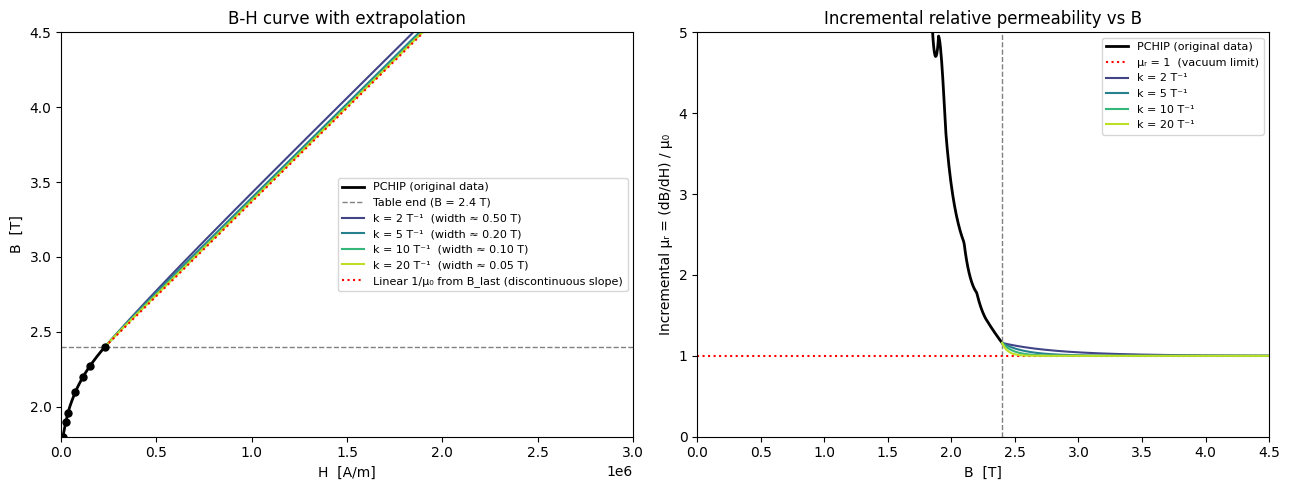

In [4]:
B_orig = np.linspace(0, B_last, 500)
B_ext  = np.linspace(B_last, 4.5, 500)

k_values = [2, 5, 10, 20]  # 1/T — transition widths of ~0.5, 0.2, 0.1, 0.05 T
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(k_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: conventional B-H curve (H on x, B on y) ---
ax = axes[0]
ax.plot(pchip(B_orig), B_orig, 'k-', lw=2, label='PCHIP (original data)')
ax.plot(H_data, B_data, 'ko', ms=5, zorder=5)
ax.axhline(B_last, color='gray', ls='--', lw=1, label=f'Table end (B = {B_last} T)')

for k, c in zip(k_values, colors):
    H_ext = extrapolate_H(B_ext, B_last, H_last, dHdB_join, k)
    ax.plot(H_ext, B_ext, color=c, lw=1.5, label=f'k = {k} T⁻¹  (width ≈ {1/k:.2f} T)')

# Reference: bare 1/μ₀ slope from B_last (linear in B-H is a line through origin)
H_air = H_last + (B_ext - B_last) / mu_0
ax.plot(H_air, B_ext, 'r:', lw=1.5, label='Linear 1/μ₀ from B_last (discontinuous slope)')

ax.set_xlabel('H  [A/m]')
ax.set_ylabel('B  [T]')
ax.set_title('B-H curve with extrapolation')
ax.legend(fontsize=8)
ax.set_xlim(0, 3e6)
ax.set_ylim(1.8, 4.5)

# --- Right: incremental relative permeability μᵣ_inc = (dB/dH) / μ₀, plotted vs B ---
ax2 = axes[1]
dHdB_orig = pchip(B_orig, 1)  # derivative dH/dB
mu_r_orig = 1 / (mu_0 * dHdB_orig)
ax2.plot(B_orig, mu_r_orig, 'k-', lw=2, label='PCHIP (original data)')
ax2.axvline(B_last, color='gray', ls='--', lw=1)
ax2.axhline(1.0, color='red', ls=':', lw=1.5, label='μᵣ = 1  (vacuum limit)')

for k, c in zip(k_values, colors):
    dHdB_e = dHdB_extrap(B_ext, B_last, dHdB_join, k)
    mu_r_e = 1 / (mu_0 * dHdB_e)
    ax2.plot(B_ext, mu_r_e, color=c, lw=1.5, label=f'k = {k} T⁻¹')

ax2.set_xlabel('B  [T]')
ax2.set_ylabel('Incremental μᵣ = (dB/dH) / μ₀')
ax2.set_title('Incremental relative permeability vs B')
ax2.set_xlim(0, 4.5)
ax2.set_ylim(0, 5)
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 4. Slope continuity verification

In [5]:
k_chosen = 10  # T⁻¹ — transition width ~0.1 T

eps = 1e-6
slope_left  = float(pchip(B_last - eps, 1))
slope_right = dHdB_extrap(B_last + eps, B_last, dHdB_join, k_chosen)

print(f"Chosen k = {k_chosen} T⁻¹  (transition width ≈ {1/k_chosen:.2f} T)")
print()
print(f"dH/dB just inside  table  : {slope_left:,.0f} A/(m·T)")
print(f"dH/dB just outside table  : {slope_right:,.0f} A/(m·T)")
print(f"Asymptotic 1/μ₀           : {1/mu_0:,.0f} A/(m·T)")

B_check = np.array([B_last + 0.1, B_last + 0.5, B_last + 1.0, B_last + 2.0])
for Bc in B_check:
    slope = dHdB_extrap(Bc, B_last, dHdB_join, k_chosen)
    mu_r  = 1 / (mu_0 * slope)
    print(f"  B = {Bc:.1f} T → dH/dB = {slope:,.0f} A/(m·T),  μᵣ_inc = {mu_r:.4f}")

Chosen k = 10 T⁻¹  (transition width ≈ 0.10 T)

dH/dB just inside  table  : 686,237 A/(m·T)
dH/dB just outside table  : 686,239 A/(m·T)
Asymptotic 1/μ₀           : 795,775 A/(m·T)
  B = 2.5 T → dH/dB = 755,479 A/(m·T),  μᵣ_inc = 1.0533
  B = 2.9 T → dH/dB = 795,037 A/(m·T),  μᵣ_inc = 1.0009
  B = 3.4 T → dH/dB = 795,770 A/(m·T),  μᵣ_inc = 1.0000
  B = 4.4 T → dH/dB = 795,775 A/(m·T),  μᵣ_inc = 1.0000


## 5. Chord (absolute) permeability check

The solver also uses the chord permeability μ = B / (μ₀ H), which must also → 1 at high B.

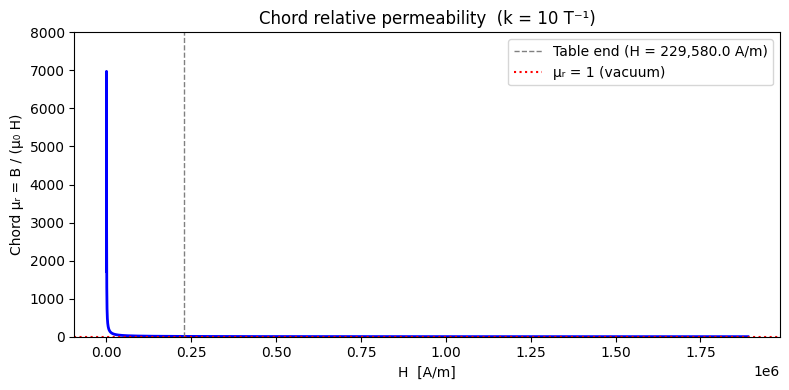

In [6]:
B_full = np.concatenate([B_orig[1:], B_ext])  # skip B=0 to avoid div-by-zero

H_orig_vals = pchip(B_orig[1:])
H_ext_vals  = extrapolate_H(B_ext, B_last, H_last, dHdB_join, k_chosen)
H_full      = np.concatenate([H_orig_vals, H_ext_vals])

mu_r_chord = B_full / (mu_0 * H_full)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(H_full, mu_r_chord, 'b-', lw=2)
ax.axvline(H_last, color='gray', ls='--', lw=1, label=f'Table end (H = {H_last:,} A/m)')
ax.axhline(1.0, color='red', ls=':', lw=1.5, label='μᵣ = 1 (vacuum)')
ax.set_xlabel('H  [A/m]')
ax.set_ylabel('Chord μᵣ = B / (μ₀ H)')
ax.set_title(f'Chord relative permeability  (k = {k_chosen} T⁻¹)')
ax.set_ylim(0, 8000)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Generate extended PMF table

Add a small number of evenly-spaced extension points. Elmer then interpolates between them with `Cubic Monotone`, so the density of points controls how faithfully the smooth curve is represented.

In [7]:
k_chosen = 10  # T⁻¹
B_ext_pts = np.array([2.5, 2.6, 2.8, 3.0, 3.5, 4.0, 5.0])  # [T]
H_ext_pts = extrapolate_H(B_ext_pts, B_last, H_last, dHdB_join, k_chosen)

B_table = np.concatenate([B_data, B_ext_pts])
H_table = np.concatenate([H_data, H_ext_pts])

print("Extended H-B table (copy into .pmf):")
print()
print("H-B Curve = Variable coupled iter")
print(" Real\t\tCubic Monotone")
for b, h in zip(B_table, H_table):
    print(f"{b}\t{h:.4g}")
print("End")

Extended H-B table (copy into .pmf):

H-B Curve = Variable coupled iter
 Real		Cubic Monotone
0.0	0
0.1	34.8
0.2	46
0.3	53.7
0.4	60.6
0.5	67.4
0.6	74.6
0.7	82.6
0.8	91.8
0.9	103
1.0	119
1.1	141
1.2	178
1.3	250
1.4	455
1.5	1180
1.6	3020
1.7	6100
1.8	1.07e+04
1.9	2.5e+04
1.956	3.5e+04
2.1	7.5e+04
2.2	1.15e+05
2.2701	1.5e+05
2.4	2.296e+05
2.5	3.022e+05
2.6	3.793e+05
2.8	5.371e+05
3.0	6.961e+05
3.5	1.094e+06
4.0	1.492e+06
5.0	2.288e+06
End


## 7. Final comparison plot

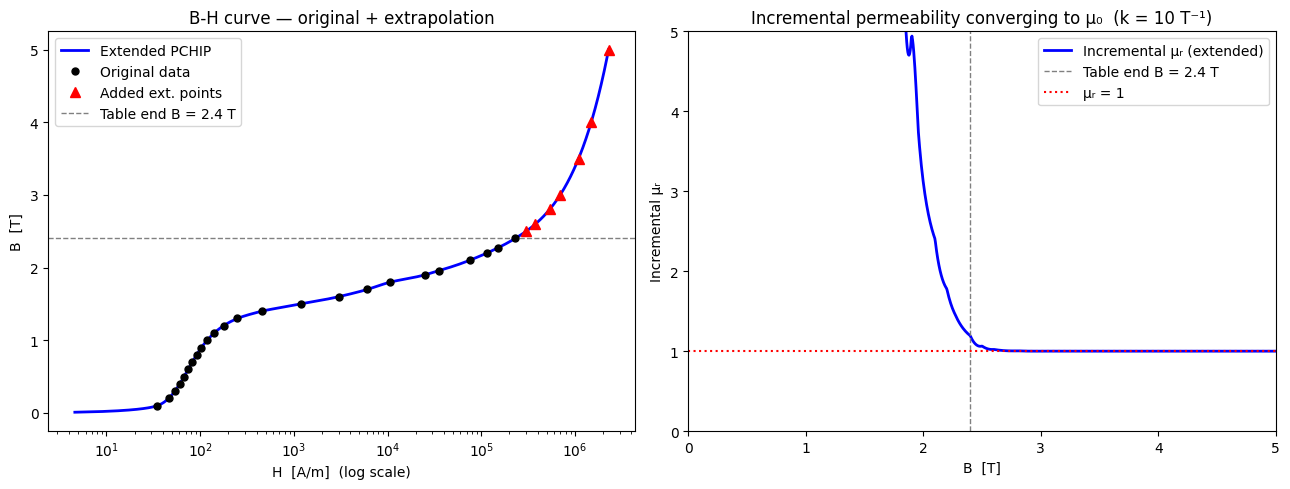

Incremental μᵣ at B = 5.0 T: 1.0000  (target: 1.0)


In [8]:
# Refit PCHIP to the extended table for a final look
pchip_ext = PchipInterpolator(B_table, H_table)

B_plot = np.linspace(0.01, 5.0, 1000)
H_plot = pchip_ext(B_plot)
mu_r_ext = 1 / (mu_0 * pchip_ext(B_plot, 1))
mu_r_ext = np.clip(mu_r_ext, 0, None)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conventional B-H curve with log H axis (H spans ~35 to millions of A/m)
ax = axes[0]
ax.semilogx(H_plot, B_plot, 'b-', lw=2, label='Extended PCHIP')
ax.semilogx(H_data, B_data, 'ko', ms=5, label='Original data', zorder=5)
ax.semilogx(H_ext_pts, B_ext_pts, 'r^', ms=7, label='Added ext. points', zorder=5)
ax.axhline(B_last, color='gray', ls='--', lw=1, label=f'Table end B = {B_last} T')
ax.set_xlabel('H  [A/m]  (log scale)')
ax.set_ylabel('B  [T]')
ax.set_title('B-H curve — original + extrapolation')
ax.legend()

# Incremental μᵣ vs B
ax2 = axes[1]
ax2.plot(B_plot, mu_r_ext, 'b-', lw=2, label='Incremental μᵣ (extended)')
ax2.axvline(B_last, color='gray', ls='--', lw=1, label=f'Table end B = {B_last} T')
ax2.axhline(1.0, color='red', ls=':', lw=1.5, label='μᵣ = 1')
ax2.set_xlabel('B  [T]')
ax2.set_ylabel('Incremental μᵣ')
ax2.set_title(f'Incremental permeability converging to μ₀  (k = {k_chosen} T⁻¹)')
ax2.set_xlim(0, 5)
ax2.set_ylim(0, 5)
ax2.legend()

fig.tight_layout()
plt.show()

# How close do we get at the last extension point?
mu_r_last_ext = 1 / (mu_0 * dHdB_extrap(B_ext_pts[-1], B_last, dHdB_join, k_chosen))
print(f"Incremental μᵣ at B = {B_ext_pts[-1]} T: {mu_r_last_ext:.4f}  (target: 1.0)")

## 8. Write extrapolated PMF file

In [9]:
k_chosen = 10  # T⁻¹

B_ext_pts = np.array([2.5, 2.6, 2.8, 3.0, 3.5, 4.0, 5.0])
H_ext_pts = extrapolate_H(B_ext_pts, B_last, H_last, dHdB_join, k_chosen)

B_table = np.concatenate([B_data, B_ext_pts])
H_table = np.concatenate([H_data, H_ext_pts])

lines = [
    "! File Generated by pyleecan v1.4.1 (extrapolated beyond 2.4 T into mu_0)",
    "! Material Name: M350-50A",
    "! B-H Curve Stator Material",
    "Electric Conductivity = 0 !2272727.27273",
    "H-B Curve = Variable coupled iter",
    " Real\t\tCubic Monotone",
]
for b, h in zip(B_table, H_table):
    lines.append(f"{b}\t{h:.6g}")
lines.append("End")

pmf_text = "\n".join(lines) + "\n"

output_path = "m350-50a_20c_extrapolated.pmf"
with open(output_path, "w") as f:
    f.write(pmf_text)

print(f"Written {output_path}")
print()
print(pmf_text)

Written m350-50a_20c_extrapolated.pmf

! File Generated by pyleecan v1.4.1 (extrapolated beyond 2.4 T into mu_0)
! Material Name: M350-50A
! B-H Curve Stator Material
Electric Conductivity = 0 !2272727.27273
H-B Curve = Variable coupled iter
 Real		Cubic Monotone
0.0	0
0.1	34.8
0.2	46
0.3	53.7
0.4	60.6
0.5	67.4
0.6	74.6
0.7	82.6
0.8	91.8
0.9	103
1.0	119
1.1	141
1.2	178
1.3	250
1.4	455
1.5	1180
1.6	3020
1.7	6100
1.8	10700
1.9	25000
1.956	35000
2.1	75000
2.2	115000
2.2701	150000
2.4	229580
2.5	302233
2.6	379264
2.8	537137
3.0	696118
3.5	1.09398e+06
4.0	1.49187e+06
5.0	2.28764e+06
End

